**2. Bosque Aleatorio**
---
Propiedad de René Adarme Amado
---
Universidad Antonio Nariño - Tesis de Maestría en Hidrogeología Ambiental
Abril de 2025

# **Librerías**

In [ ]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, roc_auc_score,
    roc_curve, make_scorer
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# **Preprocesado**

In [ ]:
# 2. Cargar y limpiar la base
base = pd.read_excel("Base_2025_v3.xlsx")
base.drop(columns=['ID', 'Tipo_Estructuras', 'Alturas'], inplace=True)

# Codificar variables categóricas
variables_numericas = base.select_dtypes(include=['float64', 'int64']).columns.tolist()
variables_numericas.remove('Agua')
variables_categoricas = base.select_dtypes(include=['object']).columns.tolist()

# Separar datos en variables predictoras y objetivo
X = base.drop(columns=['Agua'])
y = base['Agua'].astype(int)

# 3. Preprocesador
preprocesador = ColumnTransformer([
    ('numericas', StandardScaler(), variables_numericas),
    ('categoricas', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), variables_categoricas)
])

# 4. Definir las métricas de evaluación
     # Definir cómo calcular la especificidad del modelo
def especificidad_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2,2):
        return cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    return 0

# Crear diccionario con las métricas de evaluación
metricas = {
    'Exactitud': make_scorer(accuracy_score),
    'Sensibilidad': make_scorer(recall_score),
    'Especificidad': make_scorer(especificidad_score),
    'Precision': 'precision',
    'AUC-ROC': 'roc_auc',
    'Puntaje F1': 'f1'
}


#**MODELO 1**

# **Buscar k óptimo**

In [ ]:
# 5. Definir modelo base
modelo_rf_1 = ImbPipeline([
    ('preprocesador', preprocesador),
    ('smote', SMOTE(random_state=42)),
    ('clasificador', RandomForestClassifier(n_estimators=90, max_features=3, min_samples_leaf=5, random_state=42))
])

# 6. Búsqueda de k óptimo
valores_k = list(range(3, 13))
resultados_k = {}

for k in valores_k:
    resultados_cv = cross_validate(modelo_rf_1, X, y, cv=k, scoring=metricas, return_train_score=True)
    resultados_k[k] = {
        metrica: {
            'media_validacion': np.mean(resultados_cv['test_' + metrica]),
            'desviacion': np.std(resultados_cv['test_' + metrica])
        } for metrica in ['Precision', 'Sensibilidad', 'Puntaje F1', 'AUC-ROC']
    }

# 7. Seleccionar el mejor k
mejor_k = sorted(resultados_k.items(), key=lambda x: (-x[1]['Precision']['media_validacion'], x[1]['Precision']['desviacion'],
                                                       -x[1]['Sensibilidad']['media_validacion'], x[1]['Sensibilidad']['desviacion']))[0][0]

print(f"\n>>> Valor óptimo de k: {mejor_k}")



>>> Valor óptimo de k: 8


Criterios para escoger k óptimo:
*   Primero: Mayor precisión promedio (orden descendente)
*   Segundo: Menor desviación de exactitud
*   Tercero: Mayor sensibilidad promedio
*   Cuarto: Menor desviación de sensibilidad





# **Modelar con k óptimo**

In [ ]:
# 8. Entrenar Modelo 1 con k óptimo
resultados_rf_1 = cross_validate(modelo_rf_1, X, y, cv=mejor_k, scoring=metricas, return_train_score=True)

print("\nResumen de Modelo 1 con el k óptimo en ambos conjunto de datos):")
for metrica in ['Precision', 'Sensibilidad','Puntaje F1', 'AUC-ROC' ]:
    media_train = np.mean(resultados_rf_1['train_' + metrica])
    std_train = np.std(resultados_rf_1['train_' + metrica])
    media_test = np.mean(resultados_rf_1['test_' + metrica])
    std_test = np.std(resultados_rf_1['test_' + metrica])
    print(f"{metrica:<15} | Entrenamiento: {media_train:.4f} ± {std_train:.4f} | Validación: {media_test:.4f} ± {std_test:.4f}")



Resumen de Modelo 1 con el k óptimo en ambos conjunto de datos):
Precision       | Entrenamiento: 0.8922 ± 0.0054 | Validación: 0.7540 ± 0.0605
Sensibilidad    | Entrenamiento: 0.8151 ± 0.0277 | Validación: 0.6569 ± 0.3459
Puntaje F1      | Entrenamiento: 0.8516 ± 0.0152 | Validación: 0.6407 ± 0.2528
AUC-ROC         | Entrenamiento: 0.9032 ± 0.0055 | Validación: 0.6112 ± 0.2002


# **MODELOS 2 Y 3**

In [ ]:
# 9. Definir búsqueda de hiperparámetros

# Definir diccionario con los rangos de n_estimators (cantidad de árboles)
rangos_estimadores = {
    2: range(50, 101, 10),
    3: range(100, 201, 25),
}

modelos_grid1 = {}
resultados_grid1 = {}


for i in range(2, 4):
    param_grid = {
        'clasificador__n_estimators': list(rangos_estimadores[i]),
        'clasificador__max_features': [2, 3, 4, 5, 6], # número de variables consideradas al dividir cada nodo
        'clasificador__min_samples_leaf': [2, 3, 4]    # tamaño mínimo de muestra por hoja
    }

    modelo_base = ImbPipeline([
        ('preprocesador', preprocesador),                               # estandarización + codificación
        ('smote', SMOTE(random_state=42)),                              # balanceo de clases
        ('clasificador', RandomForestClassifier(random_state=42))       # Clasificador escogido
    ])

    grid = GridSearchCV(modelo_base, param_grid=param_grid, cv=mejor_k, scoring='precision', n_jobs=-1)
    grid.fit(X, y)

    print(f"\n--- Modelo {i} ---")
    print("Mejores hiperparámetros:", grid.best_params_)

    resultados = cross_validate(grid.best_estimator_, X, y, cv=mejor_k, scoring=metricas, return_train_score=True)
    resultados_grid1[i] = resultados
    modelos_grid1[i] = grid.best_estimator_

    print(f"\nResumen de métricas para Modelo {i} (k = {mejor_k}):\n")
    print(f"{'Métrica':<15}{'Conjunto':<15}{'Media':<10}{'Desviación'}")
    for metrica in ['Precision', 'Sensibilidad','Puntaje F1', 'AUC-ROC']:
        media_train = np.mean(resultados['train_' + metrica])
        std_train = np.std(resultados['train_' + metrica])
        media_val = np.mean(resultados['test_' + metrica])
        std_val = np.std(resultados['test_' + metrica])
        print(f"{metrica:<15}{'Entrenamiento':<15}{media_train:.4f}   {std_train:.4f}")
        print(f"{metrica:<15}{'Validación':<15}{media_val:.4f}   {std_val:.4f}")



--- Modelo 2 ---
Mejores hiperparámetros: {'clasificador__max_features': 2, 'clasificador__min_samples_leaf': 4, 'clasificador__n_estimators': 60}

Resumen de métricas para Modelo 2 (k = 8):

Métrica        Conjunto       Media     Desviación
Precision      Entrenamiento  0.8989   0.0068
Precision      Validación     0.7772   0.0776
Sensibilidad   Entrenamiento  0.7840   0.0339
Sensibilidad   Validación     0.6489   0.3473
Puntaje F1     Entrenamiento  0.8371   0.0194
Puntaje F1     Validación     0.6460   0.2691
AUC-ROC        Entrenamiento  0.8950   0.0059
AUC-ROC        Validación     0.6230   0.2035

--- Modelo 3 ---
Mejores hiperparámetros: {'clasificador__max_features': 2, 'clasificador__min_samples_leaf': 4, 'clasificador__n_estimators': 100}

Resumen de métricas para Modelo 3 (k = 8):

Métrica        Conjunto       Media     Desviación
Precision      Entrenamiento  0.8934   0.0088
Precision      Validación     0.7696   0.0741
Sensibilidad   Entrenamiento  0.7851   0.0312
Sensi

# **MODELOS 4 Y 5**

In [ ]:
# 10. Definir búsqueda de hiperparámetros

# Definir diccionario con los rangos de n_estimators (cantidad de árboles)
rangos_estimadores = {
    4: range(200, 301, 25),
    5: range(300, 401, 25)
}

modelos_grid2 = {}
resultados_grid2 = {}

for i in range(4, 6):
    param_grid = {
        'clasificador__n_estimators': list(rangos_estimadores[i]),
        'clasificador__max_features': [2, 3, 4, 5, 6], # número de variables consideradas al dividir cada nodo
        'clasificador__min_samples_leaf': [2, 3, 4]    # tamaño mínimo de muestra por hoja
    }

    modelo_base = ImbPipeline([
        ('preprocesador', preprocesador),                               # estandarización + codificación
        ('smote', SMOTE(random_state=42)),                              # balanceo de clases
        ('clasificador', RandomForestClassifier(random_state=42))       # Clasificador escogido
    ])

    grid = GridSearchCV(modelo_base, param_grid=param_grid, cv=mejor_k, scoring='precision', n_jobs=-1)
    grid.fit(X, y)

    print(f"\n--- Modelo {i} ---")
    print("Mejores hiperparámetros:", grid.best_params_)

    resultados = cross_validate(grid.best_estimator_, X, y, cv=mejor_k, scoring=metricas, return_train_score=True)
    resultados_grid2[i] = resultados
    modelos_grid2[i] = grid.best_estimator_

    print(f"\nResumen de métricas para Modelo {i} (k = {mejor_k}):\n")
    print(f"{'Métrica':<15}{'Conjunto':<15}{'Media':<10}{'Desviación'}")
    for metrica in ['Precision', 'Sensibilidad','Puntaje F1', 'AUC-ROC']:
        media_train = np.mean(resultados['train_' + metrica])
        std_train = np.std(resultados['train_' + metrica])
        media_val = np.mean(resultados['test_' + metrica])
        std_val = np.std(resultados['test_' + metrica])
        print(f"{metrica:<15}{'Entrenamiento':<15}{media_train:.4f}   {std_train:.4f}")
        print(f"{metrica:<15}{'Validación':<15}{media_val:.4f}   {std_val:.4f}")



--- Modelo 4 ---
Mejores hiperparámetros: {'clasificador__max_features': 2, 'clasificador__min_samples_leaf': 4, 'clasificador__n_estimators': 300}

Resumen de métricas para Modelo 4 (k = 8):

Métrica        Conjunto       Media     Desviación
Precision      Entrenamiento  0.8984   0.0143
Precision      Validación     0.7687   0.0757
Sensibilidad   Entrenamiento  0.7935   0.0331
Sensibilidad   Validación     0.6569   0.3471
Puntaje F1     Entrenamiento  0.8421   0.0178
Puntaje F1     Validación     0.6475   0.2625
AUC-ROC        Entrenamiento  0.8998   0.0056
AUC-ROC        Validación     0.6149   0.2060

--- Modelo 5 ---
Mejores hiperparámetros: {'clasificador__max_features': 2, 'clasificador__min_samples_leaf': 4, 'clasificador__n_estimators': 300}

Resumen de métricas para Modelo 5 (k = 8):

Métrica        Conjunto       Media     Desviación
Precision      Entrenamiento  0.8984   0.0143
Precision      Validación     0.7687   0.0757
Sensibilidad   Entrenamiento  0.7935   0.0331
Sens

# **Curva ROC**

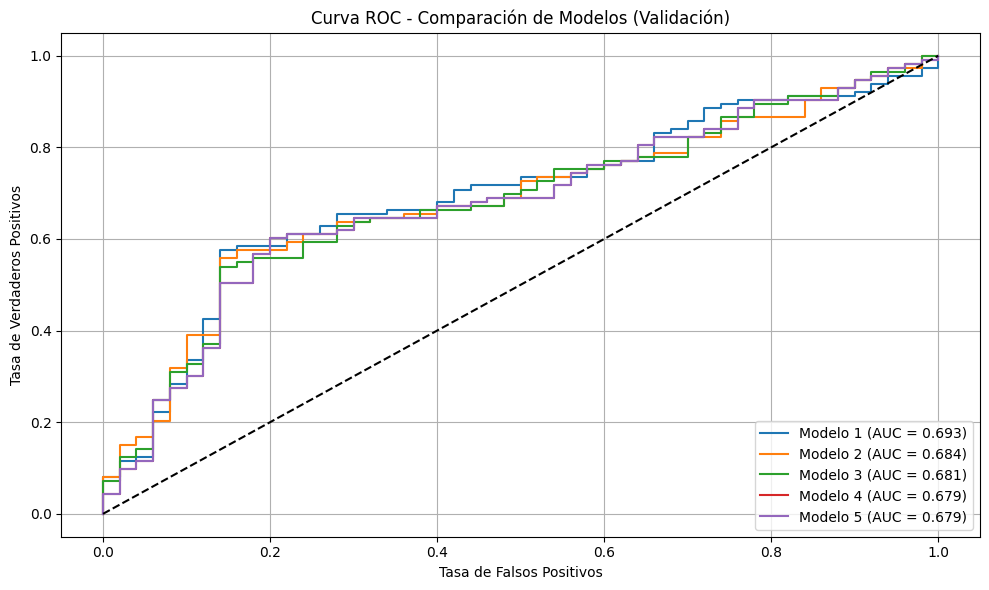

In [ ]:
# 11. Curvas ROC comparativas - Ajustado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Combinar los modelos de modelos_grid1 y modelos_grid2
modelos_finales = [modelo_rf_1] + list(modelos_grid1.values()) + list(modelos_grid2.values())

plt.figure(figsize=(10, 6))
for i, modelo in enumerate(modelos_finales):
    modelo.fit(X_train, y_train)
    probs = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"Modelo {i+1} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - Comparación de Modelos (Validación)")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()